In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score

from sklearn.ensemble import IsolationForest

In [2]:
mpg = sns.load_dataset("mpg")

X_df = mpg[["horsepower", "weight"]].dropna()
X = X_df.to_numpy()

print(X.shape)

(392, 2)


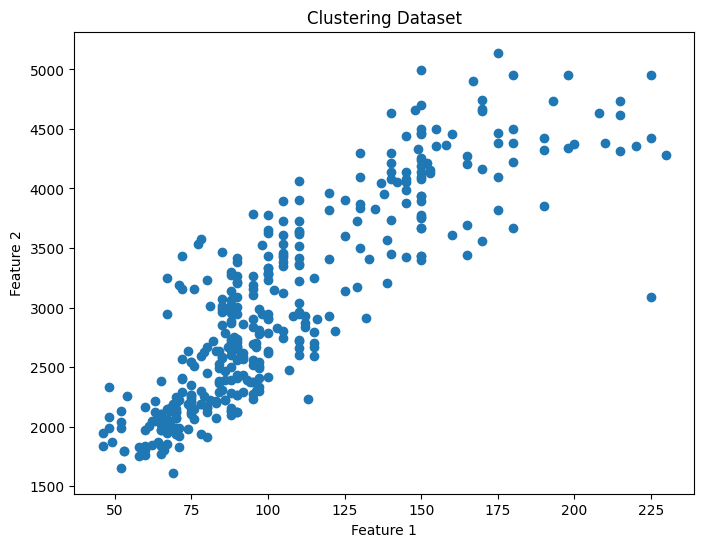

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustering Dataset")

plt.show()

In [5]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init="auto"
)

labels = kmeans.fit_predict(X)

In [6]:
cluster_counts = pd.Series(
    labels
).value_counts().sort_index()

print(cluster_counts)

0    138
1     85
2    104
3     65
Name: count, dtype: int64


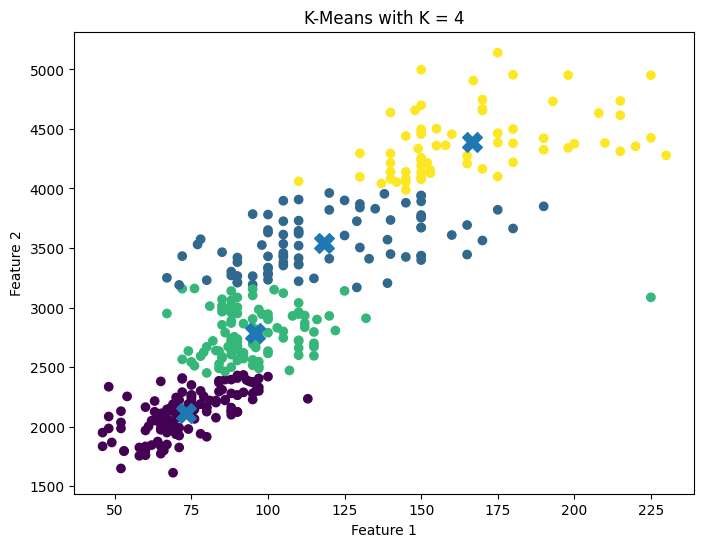

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means with K = 4")

plt.show()

In [8]:
kmeans.inertia_

18150931.877632007

In [9]:
print("Inertia:", kmeans.inertia_)

Inertia: 18150931.877632007


In [10]:
inertias = []

k_values = range(1, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X)

    inertias.append(
        model.inertia_
    )

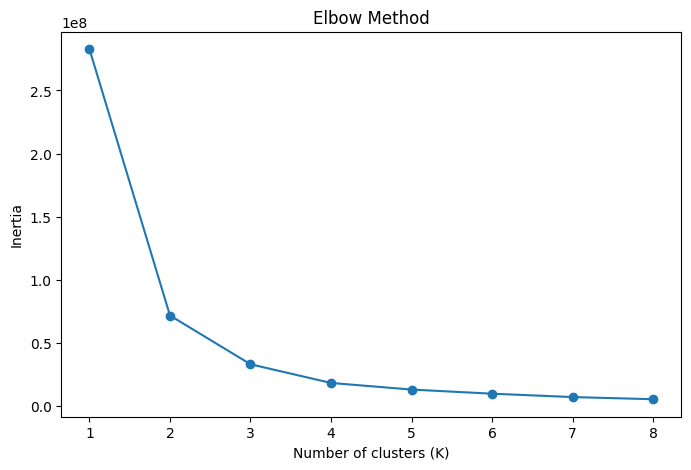

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [12]:
silhouette_results = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    labels_k = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels_k
    )

    silhouette_results.append({
        "K": k,
        "Silhouette": score
    })

silhouette_results = pd.DataFrame(
    silhouette_results
)

silhouette_results

,K,Silhouette
0,2,0.639148
1,3,0.591051
2,4,0.587017
3,5,0.564529
4,6,0.529039
5,7,0.535717
6,8,0.531939


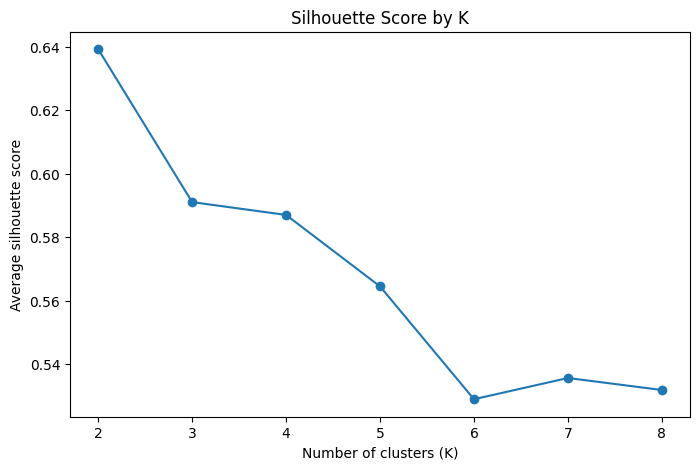

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Score by K")

plt.show()

In [14]:
tips = sns.load_dataset("tips").dropna()

X_scale_demo = tips[["total_bill", "size"]].copy()

In [15]:
X_scale_demo.describe()

,total_bill,size
count,244.000000,244.000000
mean,19.785943,2.569672
std,8.902412,0.951100
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.000000
75%,24.127500,3.000000
max,50.810000,6.000000


In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_scale_demo
)

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
kmeans_scaled = KMeans(
    n_clusters=4,
    random_state=42,
    n_init="auto"
)

labels_scaled = kmeans_scaled.fit_predict(
    X_scaled
)

In [19]:
print(labels[:20])
print(labels_scaled[:20])

[1 1 1 1 1 3 3 3 3 1 1 1 1 2 0 2 2 2 0 0]
[1 1 1 1 1 3 3 3 3 3 1 1 1 3 0 2 2 0 0 0]


In [20]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

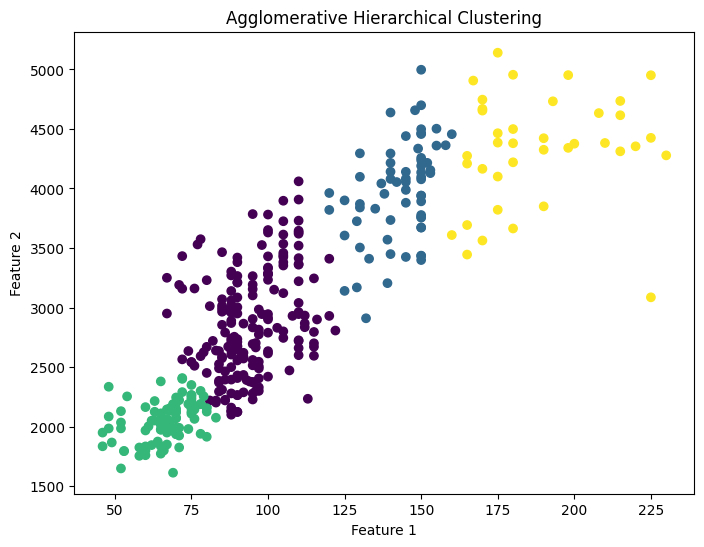

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=hierarchical_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")

plt.show()

In [22]:
!pip install -q scipy

In [23]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

In [24]:
Z = linkage(
    X_scaled,
    method="ward"
)

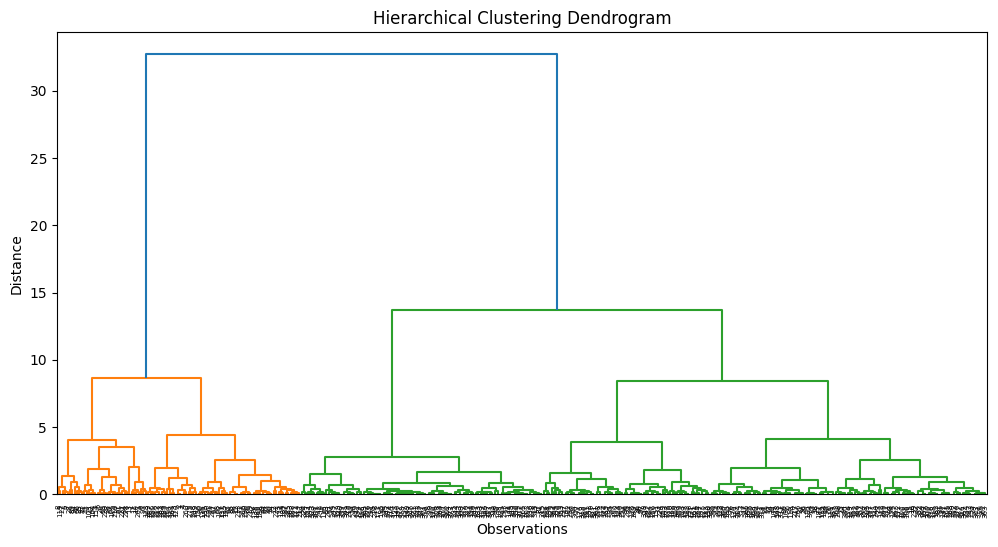

In [25]:
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [26]:
linkage_methods = [
    "ward",
    "complete",
    "average",
    "single"
]

for method in linkage_methods:

    if method == "ward":
        model = AgglomerativeClustering(
            n_clusters=4,
            linkage=method
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=4,
            linkage=method
        )

    labels_method = model.fit_predict(
        X_scaled
    )

    print(
        method,
        np.bincount(labels_method)
    )

ward [187  65 102  38]
complete [ 87  10  94 201]
average [292  31   1  68]
single [388   1   2   1]


In [34]:
!wget https://raw.githubusercontent.com/AI-Learning-Repo/Data-Handling/refs/heads/week5/datasets/credit_card.csv

--2026-09-20 15:03:34--  https://raw.githubusercontent.com/AI-Learning-Repo/Data-Handling/refs/heads/week5/datasets/credit_card.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 893928 (873K) [text/plain]
Saving to: ‘credit_card.csv’

credit_card.csv     100%[===================>] 872.98K  --.-KB/s    in 0.05s   

2026-09-20 15:03:35 (18.9 MB/s) - ‘credit_card.csv’ saved [893928/893928]



In [35]:
import pandas as pd

credit_card = pd.read_csv("credit_card.csv")

# Remove the identifier because it is not a behavioral feature.
credit_card = credit_card.drop(columns=["CUST_ID"])

# Use numeric features and handle missing values.
X_anomaly_df = credit_card.select_dtypes(
    include="number"
).copy()

X_anomaly_df = X_anomaly_df.fillna(
    X_anomaly_df.median()
)

X_anomaly_demo = X_anomaly_df.to_numpy()

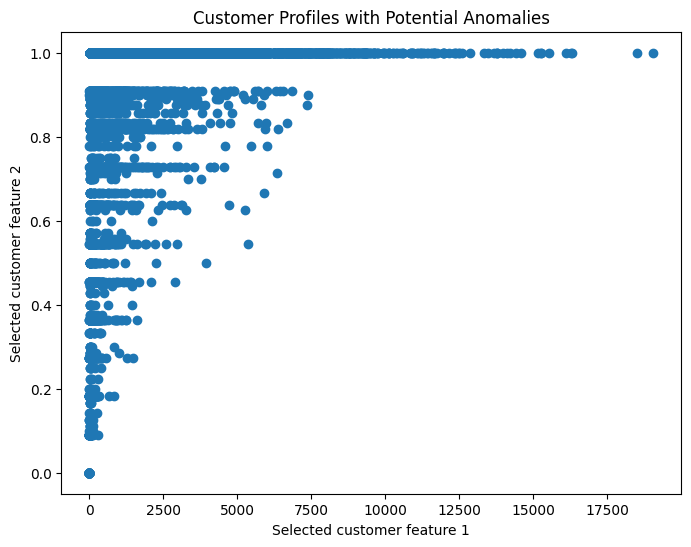

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_anomaly_demo[:, 0],
    X_anomaly_demo[:, 1]
)

plt.xlabel("Selected customer feature 1")
plt.ylabel("Selected customer feature 2")
plt.title("Customer Profiles with Potential Anomalies")

plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

anomaly_scaler = StandardScaler()
X_anomaly_scaled = anomaly_scaler.fit_transform(
    X_anomaly_demo
)

isolation_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

In [39]:
from sklearn.preprocessing import StandardScaler

anomaly_scaler = StandardScaler()
X_anomaly_scaled = anomaly_scaler.fit_transform(
    X_anomaly_demo
)

isolation_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

In [40]:
anomaly_labels = isolation_model.fit_predict(
    X_anomaly_scaled
)

In [41]:
print(
    pd.Series(anomaly_labels).value_counts()
)

 1    8771
-1     179
Name: count, dtype: int64


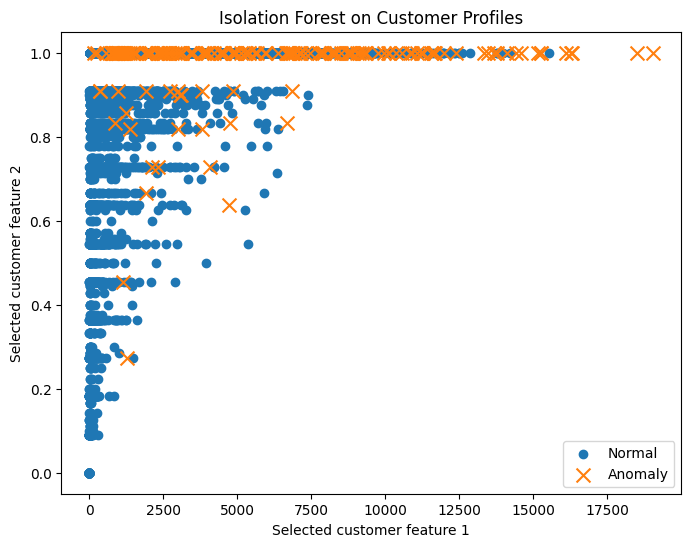

In [42]:
normal = anomaly_labels == 1
anomalies = anomaly_labels == -1

plt.figure(figsize=(8, 6))

plt.scatter(
    X_anomaly_demo[normal, 0],
    X_anomaly_demo[normal, 1],
    label="Normal"
)

plt.scatter(
    X_anomaly_demo[anomalies, 0],
    X_anomaly_demo[anomalies, 1],
    marker="x",
    s=100,
    label="Anomaly"
)

plt.xlabel("Selected customer feature 1")
plt.ylabel("Selected customer feature 2")
plt.title("Isolation Forest on Customer Profiles")

plt.legend()
plt.show()

In [43]:
!pip install -q mlxtend

In [47]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

In [48]:
transactions = [
    ["Bread", "Butter", "Milk"],
    ["Bread", "Butter"],
    ["Bread", "Milk"],
    ["Butter", "Milk"],
    ["Bread", "Butter", "Milk"],
    ["Bread", "Butter"],
    ["Milk"],
    ["Bread", "Milk"]
]

In [49]:
encoder = TransactionEncoder()

encoded = encoder.fit(
    transactions
).transform(
    transactions
)

In [50]:
transaction_df = pd.DataFrame(
    encoded,
    columns=encoder.columns_
)

transaction_df

,Bread,Butter,Milk
0,True,True,True
1,True,True,False
2,True,False,True
3,False,True,True
4,True,True,True
5,True,True,False
6,False,False,True
7,True,False,True


In [51]:
frequent_itemsets = apriori(
    transaction_df,
    min_support=0.3,
    use_colnames=True
)

frequent_itemsets

,support,itemsets
0,0.750,(Bread)
1,0.625,(Butter)
2,0.750,(Milk)
3,0.500,"(Butter, Bread)"
4,0.500,"(Bread, Milk)"
5,0.375,"(Butter, Milk)"


In [52]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Butter),(Bread),0.625,0.750,0.500,0.800000,1.066667,1.0,0.03125,1.250,0.166667,0.571429,0.200000,0.733333
1,(Bread),(Butter),0.750,0.625,0.500,0.666667,1.066667,1.0,0.03125,1.125,0.250000,0.571429,0.111111,0.733333
2,(Bread),(Milk),0.750,0.750,0.500,0.666667,0.888889,1.0,-0.06250,0.750,-0.333333,0.500000,-0.333333,0.666667
3,(Milk),(Bread),0.750,0.750,0.500,0.666667,0.888889,1.0,-0.06250,0.750,-0.333333,0.500000,-0.333333,0.666667
4,(Butter),(Milk),0.625,0.750,0.375,0.600000,0.800000,1.0,-0.09375,0.625,-0.400000,0.375000,-0.600000,0.550000
5,(Milk),(Butter),0.750,0.625,0.375,0.500000,0.800000,1.0,-0.09375,0.750,-0.500000,0.375000,-0.333333,0.550000


In [53]:
results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    labels_k = model.fit_predict(X_scaled)

    inertia = model.inertia_

    silhouette = silhouette_score(
        X_scaled,
        labels_k
    )

    results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette": silhouette
    })

results_df = pd.DataFrame(results)

results_df

,K,Inertia,Silhouette
0,2,241.703743,0.615080
1,3,136.274240,0.499204
2,4,98.508865,0.480519
3,5,86.082463,0.438765
4,6,64.245272,0.427650


In [55]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create a sample customer dataset
customer_df = pd.DataFrame({
    "Age": [22, 25, 28, 35, 40, 45, 50, 52, 60],
    "Income": [25, 30, 35, 50, 55, 65, 75, 80, 90],
    "Spending": [80, 75, 70, 60, 55, 45, 35, 30, 20]
})

# Select the features used for clustering
features = ["Age", "Income", "Spending"]

X_customer = customer_df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customer)

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original DataFrame
customer_df["Cluster"] = labels

# Calculate the average characteristics of each cluster
profile = customer_df.groupby("Cluster")[
    [
        "Age",
        "Income",
        "Spending"
    ]
].mean()

profile

,Age,Income,Spending
Cluster,,,
0,25.0,30.000000,75.000000
1,54.0,81.666667,28.333333
2,40.0,56.666667,53.333333
